In [2]:
import numpy as np
import pandas as pd

In [3]:
# mount google drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
### list the files in the directory
# import os
# os.listdir('drive/MyDrive/MLData')

In [5]:
df = pd.read_csv('drive/MyDrive/MLData/placement.csv')
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [6]:
df.shape

(100, 4)

### Preprocess + EDA + Feature selection

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [8]:
# drop the first column as it is just an index
# df.iloc[:, 1:] will select all rows and all columns except the first one
remove_col_df = df.iloc[:, 1:]
remove_col_df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [9]:
import matplotlib.pyplot as plt

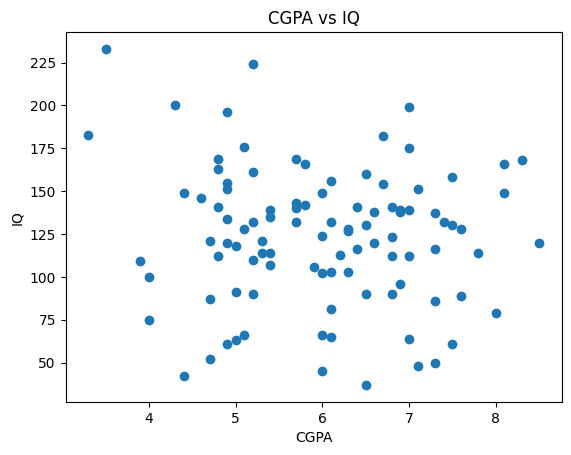

In [10]:
plt.scatter(remove_col_df['cgpa'], remove_col_df['iq'])
plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.title('CGPA vs IQ')

plt.show()

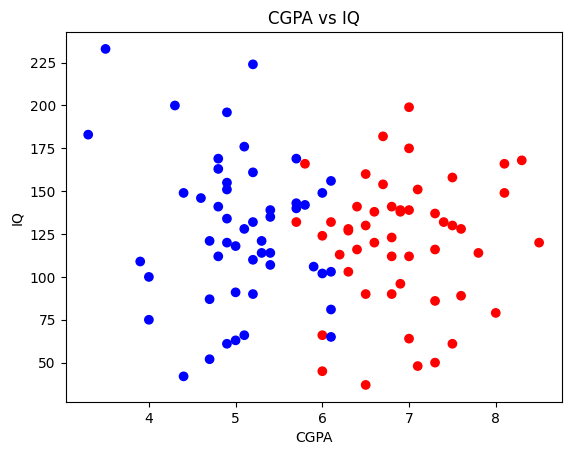

In [12]:
plt.scatter(remove_col_df['cgpa'], remove_col_df['iq'], c=remove_col_df['placement'], cmap='bwr')
plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.title('CGPA vs IQ')

plt.show()

### Extract input and output columns

In [13]:
x = remove_col_df.iloc[:, 0:2]
y = remove_col_df.iloc[:, -1]

In [14]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [15]:
x.shape

(100, 2)

In [16]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [17]:
y.shape

(100,)

### Train test split

In [18]:
from sklearn.model_selection import train_test_split

## split the data into training and testing sets with 10% of the data as test set

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1)

In [19]:
x_train

,cgpa,iq
13,6.4,116.0
10,6.0,45.0
65,8.1,166.0
52,7.0,175.0
61,7.3,137.0
...,...,...
51,4.8,141.0
97,6.7,182.0
12,5.4,139.0
44,7.5,61.0


In [20]:
y_train

,placement
13,1
10,1
65,1
52,1
61,1
...,...
51,0
97,1
12,0
44,1


In [21]:
x_test

,cgpa,iq
8,6.1,156.0
96,4.4,42.0
94,4.7,52.0
90,7.3,86.0
6,5.7,143.0
85,5.8,166.0
42,7.6,89.0
28,5.2,90.0
40,4.9,134.0
21,7.1,151.0


In [22]:
y_test

,placement
8,0
96,0
94,0
90,1
6,0
85,1
42,1
28,0
40,0
21,1


### Scale the values

In [23]:
from sklearn.preprocessing import StandardScaler

In [24]:
scaler = StandardScaler()

In [25]:
x_train = scaler.fit_transform(x_train)

In [26]:
x_train

array([[ 0.34673253, -0.22940845],
       [-0.00291372, -2.04142325],
       [ 1.83272911,  1.04665832],
       [ 0.87120191,  1.27635033],
       [ 1.1334366 ,  0.30653959],
       [ 0.25932097,  0.05132624],
       [ 0.78379035,  0.33206093],
       [-0.87702935, -0.86744183],
       [-0.26514841,  1.12322232],
       [-0.5273831 ,  0.25549692],
       [ 1.1334366 , -0.22940845],
       [-0.70220623, -0.38253646],
       [-0.70220623,  0.17893292],
       [-0.96444091, -0.12732311],
       [ 1.30825973,  0.84248763],
       [-0.78961779,  0.07684758],
       [ 0.52155566, -0.12732311],
       [ 0.25932097,  0.07684758],
       [-2.36302593,  1.48052101],
       [-0.17773685,  0.43414627],
       [-1.75114498, -1.27578319],
       [ 1.83272911,  0.61279562],
       [ 0.25932097, -0.56118581],
       [ 1.39567129,  0.07684758],
       [ 0.69637879,  0.40862493],
       [ 0.08449784,  0.17893292],
       [ 0.87120191,  1.88886238],
       [ 0.87120191, -0.33149379],
       [ 0.87120191,

In [35]:
x_test = scaler.transform(x_test)

In [36]:
x_test

array([[ 0.08449784,  0.79144496],
       [-1.40149873, -2.11798726],
       [-1.13926404, -1.8627739 ],
       [ 1.1334366 , -0.9950485 ],
       [-0.26514841,  0.4596676 ],
       [-0.17773685,  1.04665832],
       [ 1.39567129, -0.9184845 ],
       [-0.70220623, -0.89296316],
       [-0.96444091,  0.22997559],
       [ 0.95861348,  0.66383829]])

### Model training

##### Try with LogisticRegression

In [37]:
from sklearn.linear_model import LogisticRegression

In [38]:
clf = LogisticRegression()

In [39]:
# model training
clf.fit(x_train, y_train)

LogisticRegression()

In [40]:
y_pred = clf.predict(x_test)
y_pred

array([1, 0, 0, 1, 0, 0, 1, 0, 0, 1])

In [41]:
y_test

,placement
8,0
96,0
94,0
90,1
6,0
85,1
42,1
28,0
40,0
21,1


##### Try with Decision

In [44]:
from sklearn.tree import DecisionTreeClassifier

In [45]:
rand_clf = DecisionTreeClassifier()

In [47]:
rand_clf.fit(x_train, y_train)

DecisionTreeClassifier()

In [48]:
y_pred = rand_clf.predict(x_test)

In [49]:
y_pred

array([0, 0, 0, 1, 0, 0, 1, 0, 0, 1])

### Evaluate the model

In [52]:
from sklearn.metrics import accuracy_score

In [53]:
accuracy_score(y_test, y_pred)

0.9

In [56]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

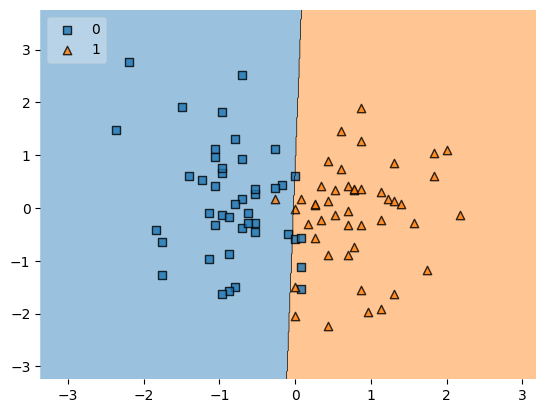

In [64]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

### Deploy the model

In [65]:
import pickle

In [66]:
# save the model to a file named 'model.pkl' in google drive
pickle.dump(clf, open('drive/MyDrive/MLData/model.pkl', 'wb'))

### Using the saved model to predict more values

In [ ]:
# Load the model
model = pickle.load(open('drive/MyDrive/MLData/model.pkl', 'rb'))

# Example new data
new_data = pd.DataFrame({
    'cgpa': [5, 8.2],
    'iq': [120, 135]
})

new_data_test = scaler.transform(new_data)

# Predict
predictions = model.predict(new_data_test)

print(predictions)

[0 1]
